In [1]:
# ============================================================
# RETAIL SUPPLY CHAIN INTELLIGENCE
# Notebook: Business Analytics & SQL Insights
# Day 2 - Answering Real Business Questions
# ============================================================

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

print("="*50)
print("All Libraries Loaded Successfully!")
print("="*50)

All Libraries Loaded Successfully!


In [2]:
# Connect to SQL Warehouse
import os

db_path = os.path.join('..', 'data', 'warehouse', 'retail_warehouse.db')
conn = sqlite3.connect(db_path)

# Load all tables
orders = pd.read_sql("SELECT * FROM dim_orders", conn)
customers = pd.read_sql("SELECT * FROM dim_customers", conn)
products = pd.read_sql("SELECT * FROM dim_products", conn)
order_items = pd.read_sql("SELECT * FROM fact_order_items", conn)
payments = pd.read_sql("SELECT * FROM fact_payments", conn)
reviews = pd.read_sql("SELECT * FROM fact_reviews", conn)
sellers = pd.read_sql("SELECT * FROM dim_sellers", conn)
master = pd.read_sql("SELECT * FROM master_dataset", conn)

print("="*50)
print("DATABASE CONNECTED SUCCESSFULLY!")
print("="*50)
print(f"Orders : {orders.shape[0]:,} rows")
print(f"Customers : {customers.shape[0]:,} rows")
print(f"Products : {products.shape[0]:,} rows")
print(f"Order Items : {order_items.shape[0]:,} rows")
print(f"Payments : {payments.shape[0]:,} rows")
print(f"Reviews : {reviews.shape[0]:,} rows")
print(f"Sellers : {sellers.shape[0]:,} rows")
print(f"Master : {master.shape[0]:,} rows")

DATABASE CONNECTED SUCCESSFULLY!
Orders : 99,441 rows
Customers : 99,441 rows
Products : 32,951 rows
Order Items : 112,650 rows
Payments : 103,877 rows
Reviews : 98,410 rows
Sellers : 3,095 rows
Master : 99,684 rows


In [3]:
# BUSINESS QUESTION 1:
# What is our overall business performance?

query1 = """
SELECT 
    COUNT(DISTINCT o.order_id) as total_orders,
    COUNT(DISTINCT o.customer_id) as total_customers,
    ROUND(SUM(p.payment_value), 2) as total_revenue,
    ROUND(AVG(p.payment_value), 2) as avg_order_value,
    ROUND(MAX(p.payment_value), 2) as max_order_value,
    ROUND(MIN(p.payment_value), 2) as min_order_value
FROM dim_orders o
JOIN fact_payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
"""

result1 = pd.read_sql(query1, conn)
print("="*50)
print("BUSINESS PERFORMANCE OVERVIEW")
print("="*50)
print(result1.to_string(index=False))

BUSINESS PERFORMANCE OVERVIEW
 total_orders  total_customers  total_revenue  avg_order_value  max_order_value  min_order_value
        96477            96477    15422461.77           153.07         13664.08             0.01


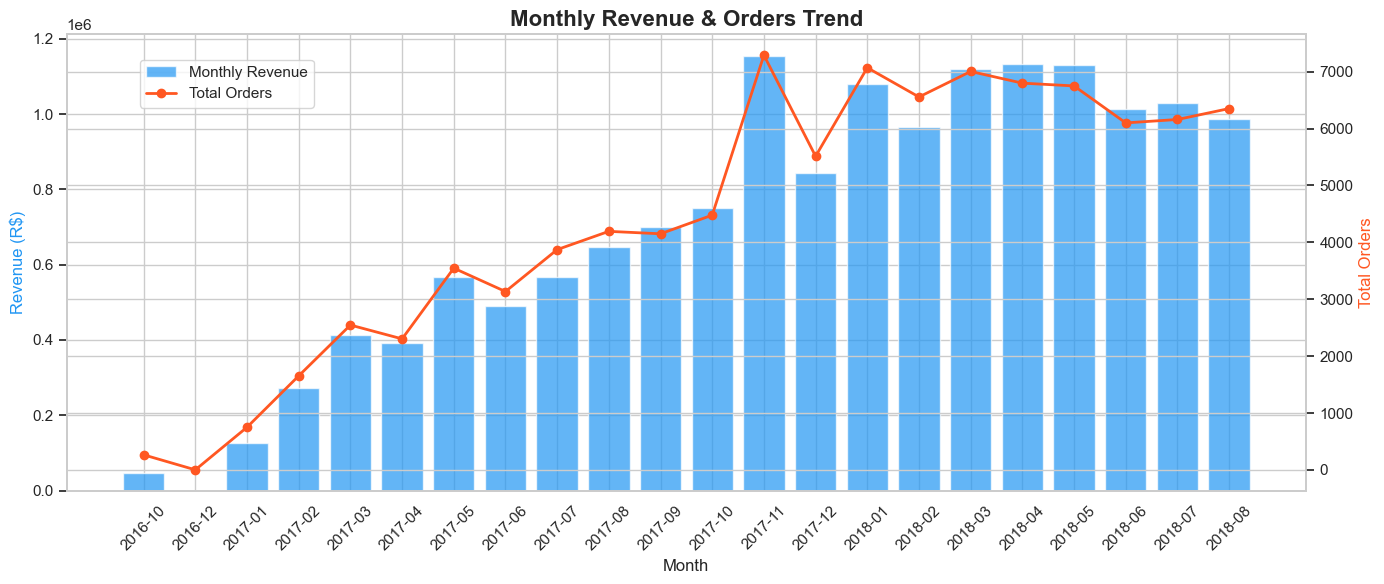

Chart saved to reports folder!


In [4]:

# BUSINESS QUESTION 2:
# How has our revenue grown month over month?

query2 = """
SELECT 
    strftime('%Y-%m', o.order_purchase_timestamp) as month,
    COUNT(DISTINCT o.order_id) as total_orders,
    ROUND(SUM(p.payment_value), 2) as monthly_revenue
FROM dim_orders o
JOIN fact_payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
AND o.order_purchase_timestamp IS NOT NULL
GROUP BY month
ORDER BY month
"""

revenue_trend = pd.read_sql(query2, conn)
revenue_trend = revenue_trend[revenue_trend['month'] != 'None']

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2196F3'
color2 = '#FF5722'

ax1.bar(revenue_trend['month'], revenue_trend['monthly_revenue'], 
        color=color1, alpha=0.7, label='Monthly Revenue')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Revenue (R$)', color=color1, fontsize=12)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(revenue_trend['month'], revenue_trend['total_orders'], 
         color=color2, marker='o', linewidth=2, label='Total Orders')
ax2.set_ylabel('Total Orders', color=color2, fontsize=12)

plt.title('Monthly Revenue & Orders Trend', fontsize=16, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('../reports/monthly_revenue_trend.png', dpi=150)
plt.show()
print("Chart saved to reports folder!")

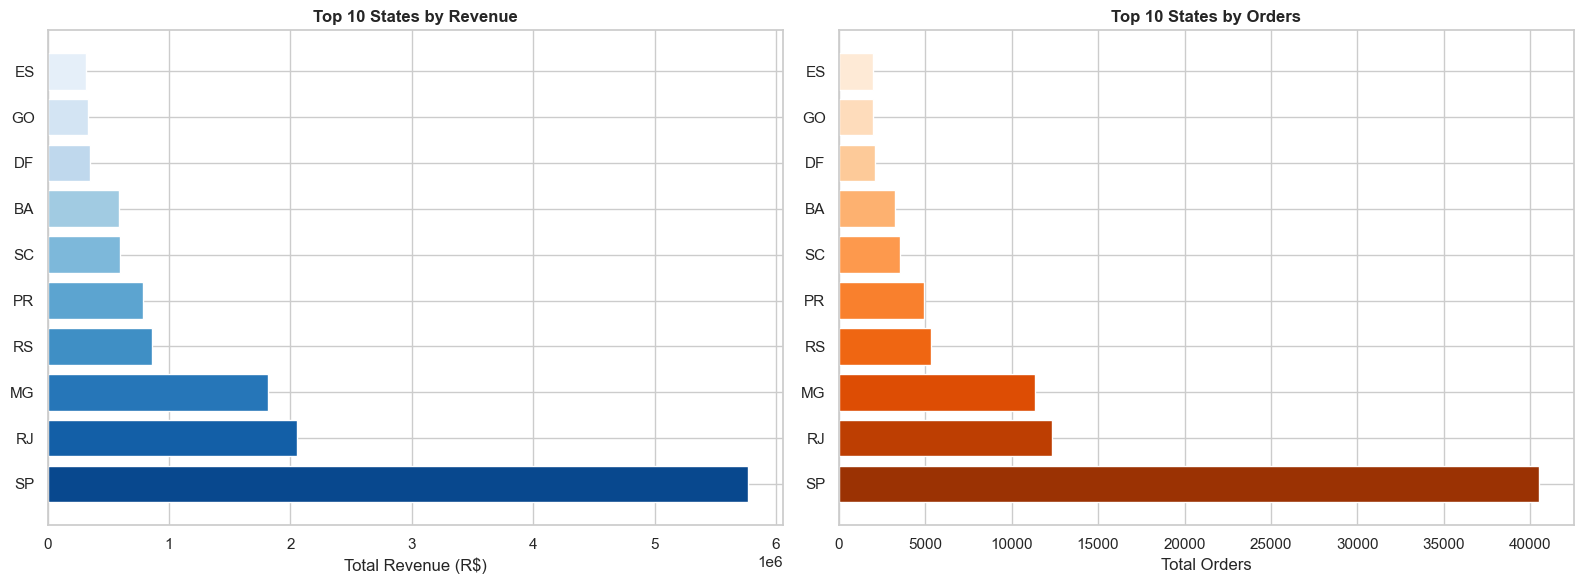


Top 10 States Revenue Table:
customer_state  total_orders  unique_customers  total_revenue  avg_order_value
            SP         40500             40500     5770266.19           136.39
            RJ         12350             12350     2055690.45           158.11
            MG         11354             11354     1819277.61           154.12
            RS          5345              5345      861802.40           155.45
            PR          4923              4923      781919.55           152.45
            SC          3546              3546      595208.40           162.58
            BA          3256              3256      591270.60           169.76
            DF          2080              2080      346146.17           161.60
            GO          1957              1957      334294.22           163.39
            ES          1995              1995      317682.65           153.69


In [5]:
# BUSINESS QUESTION 3:
# Which states generate the most revenue?

query3 = """
SELECT 
    c.customer_state,
    COUNT(DISTINCT o.order_id) as total_orders,
    COUNT(DISTINCT o.customer_id) as unique_customers,
    ROUND(SUM(p.payment_value), 2) as total_revenue,
    ROUND(AVG(p.payment_value), 2) as avg_order_value
FROM dim_orders o
JOIN dim_customers c ON o.customer_id = c.customer_id
JOIN fact_payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10
"""

top_states = pd.read_sql(query3, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue by state
axes[0].barh(top_states['customer_state'], 
             top_states['total_revenue'],
             color=sns.color_palette("Blues_r", 10))
axes[0].set_title('Top 10 States by Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (R$)')

# Orders by state
axes[1].barh(top_states['customer_state'],
             top_states['total_orders'],
             color=sns.color_palette("Oranges_r", 10))
axes[1].set_title('Top 10 States by Orders', fontweight='bold')
axes[1].set_xlabel('Total Orders')

plt.tight_layout()
plt.savefig('../reports/top_states_analysis.png', dpi=150)
plt.show()

print("\nTop 10 States Revenue Table:")
print(top_states.to_string(index=False))

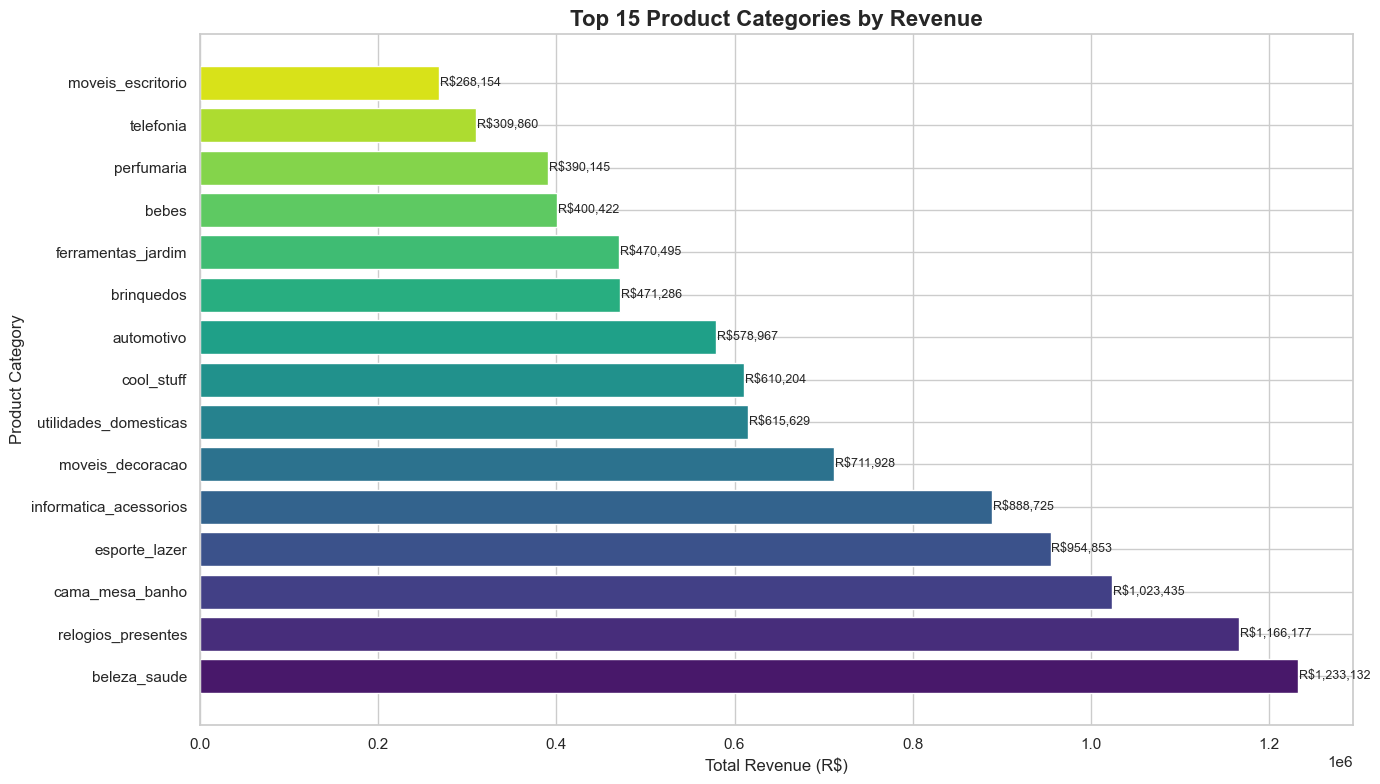


Top 15 Categories Table:
 product_category_name  total_orders  total_items_sold  total_revenue  avg_price  total_freight
          beleza_saude          8647             10849     1233131.72     130.28      178957.81
    relogios_presentes          5495              6459     1166176.98     199.04       98156.14
       cama_mesa_banho          9272             13485     1023434.76      93.44      201774.50
         esporte_lazer          7530              9698      954852.55     113.25      163404.36
informatica_acessorios          6530              9650      888724.61     116.26      143999.16
      moveis_decoracao          6307             11302      711927.69      87.25      168402.23
 utilidades_domesticas          5743              8831      615628.69      90.60      142763.56
            cool_stuff          3559              3993      610204.10     164.12       81476.79
            automotivo          3810              4772      578966.65     139.85       90488.10
            br

In [6]:
# BUSINESS QUESTION 4:
# Which product categories drive the most revenue?

query4 = """
SELECT 
    p.product_category_name,
    COUNT(DISTINCT oi.order_id) as total_orders,
    SUM(oi.order_item_id) as total_items_sold,
    ROUND(SUM(oi.price), 2) as total_revenue,
    ROUND(AVG(oi.price), 2) as avg_price,
    ROUND(SUM(oi.freight_value), 2) as total_freight
FROM fact_order_items oi
JOIN dim_products p ON oi.product_id = p.product_id
JOIN dim_orders o ON oi.order_id = o.order_id
WHERE o.order_status = 'delivered'
AND p.product_category_name != 'unknown'
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 15
"""

category_perf = pd.read_sql(query4, conn)

plt.figure(figsize=(14, 8))
bars = plt.barh(category_perf['product_category_name'],
                category_perf['total_revenue'],
                color=sns.color_palette("viridis", 15))
plt.title('Top 15 Product Categories by Revenue', 
          fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

for i, (value, bar) in enumerate(zip(category_perf['total_revenue'], bars)):
    plt.text(value + 1000, bar.get_y() + bar.get_height()/2,
             f'R${value:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/category_performance.png', dpi=150)
plt.show()

print("\nTop 15 Categories Table:")
print(category_perf.to_string(index=False))

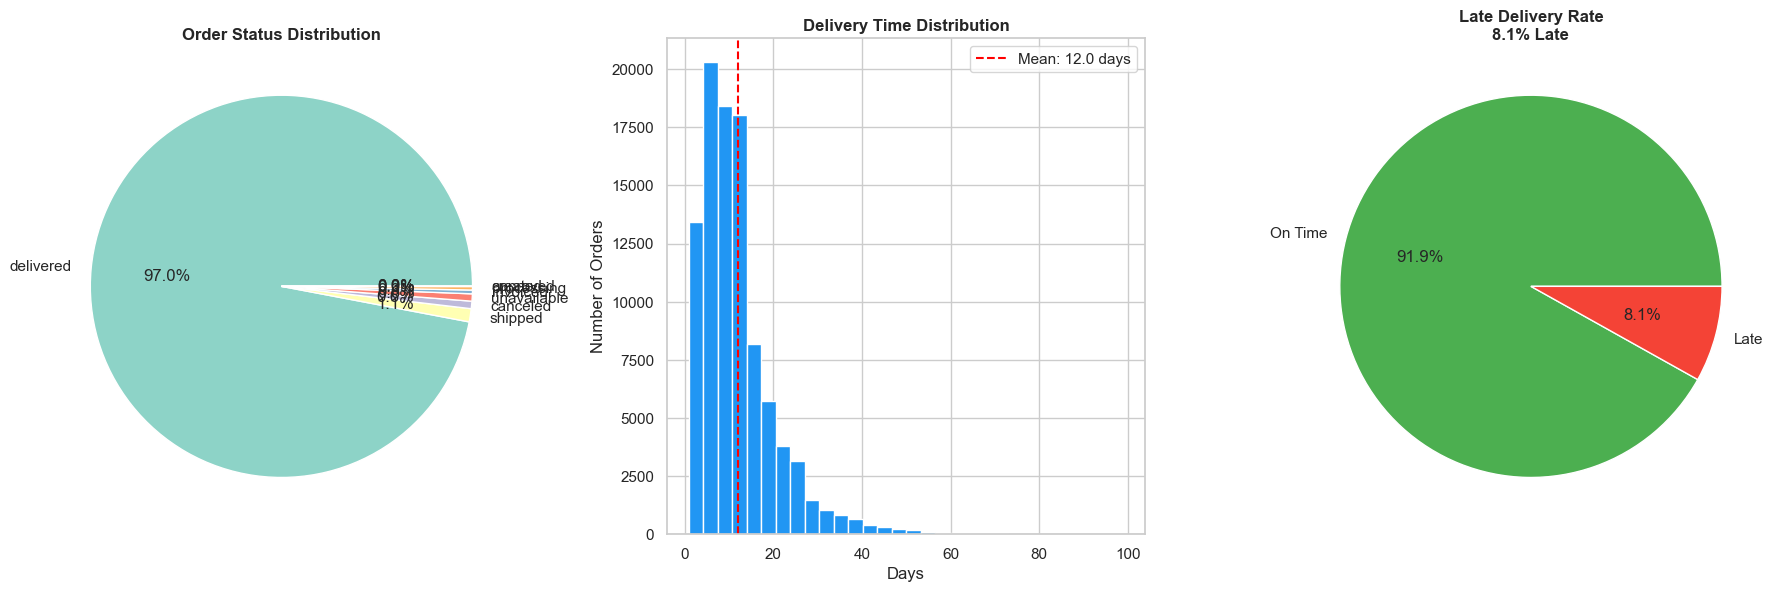


Average Delivery Time: 12.0 days
Late Delivery Rate: 8.1%

Order Status Breakdown:
order_status  total_orders  percentage
   delivered         96478       97.02
     shipped          1107        1.11
    canceled           625        0.63
 unavailable           609        0.61
    invoiced           314        0.32
  processing           301        0.30
     created             5        0.01
    approved             2        0.00


In [7]:
# BUSINESS QUESTION 5:
# How is our delivery performance? What is our late delivery rate?

query5 = """
SELECT
    order_status,
    COUNT(*) as total_orders,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM dim_orders
GROUP BY order_status
ORDER BY total_orders DESC
"""

order_status = pd.read_sql(query5, conn)

# Delivery time analysis from master
master['order_purchase_timestamp'] = pd.to_datetime(
    master['order_purchase_timestamp'], errors='coerce')
master['order_delivered_customer_date'] = pd.to_datetime(
    master['order_delivered_customer_date'], errors='coerce')
master['order_estimated_delivery_date'] = pd.to_datetime(
    master['order_estimated_delivery_date'], errors='coerce')

master['delivery_time_days'] = (
    master['order_delivered_customer_date'] - 
    master['order_purchase_timestamp']
).dt.days

master['is_late'] = (
    master['order_delivered_customer_date'] > 
    master['order_estimated_delivery_date']
).astype(int)

delivered = master[master['order_status'] == 'delivered'].copy()
late_rate = delivered['is_late'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Order status pie
axes[0].pie(order_status['total_orders'],
            labels=order_status['order_status'],
            autopct='%1.1f%%',
            colors=sns.color_palette("Set3"))
axes[0].set_title('Order Status Distribution', fontweight='bold')

# Delivery time distribution
delivery_clean = delivered['delivery_time_days'].dropna()
delivery_clean = delivery_clean[(delivery_clean > 0) & (delivery_clean < 100)]
axes[1].hist(delivery_clean, bins=30, color='#2196F3', edgecolor='white')
axes[1].axvline(delivery_clean.mean(), color='red', 
                linestyle='--', label=f'Mean: {delivery_clean.mean():.1f} days')
axes[1].set_title('Delivery Time Distribution', fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of Orders')
axes[1].legend()

# Late vs On time
late_counts = delivered['is_late'].value_counts()
axes[2].pie(late_counts,
            labels=['On Time', 'Late'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'])
axes[2].set_title(f'Late Delivery Rate\n{late_rate:.1f}% Late', 
                  fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/delivery_performance.png', dpi=150)
plt.show()

print(f"\nAverage Delivery Time: {delivery_clean.mean():.1f} days")
print(f"Late Delivery Rate: {late_rate:.1f}%")
print(f"\nOrder Status Breakdown:")
print(order_status.to_string(index=False))

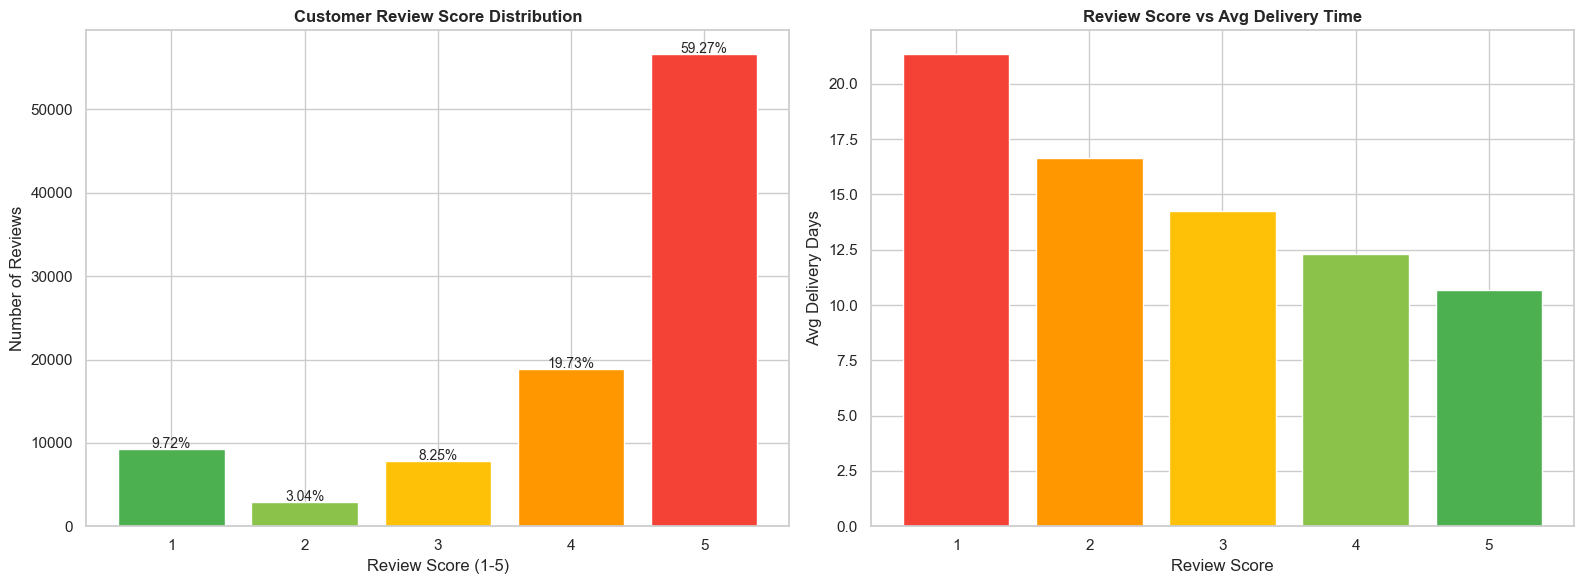


Review Score Analysis:
 review_score  total_reviews  percentage
            5          56664       59.27
            4          18861       19.73
            3           7884        8.25
            2           2908        3.04
            1           9292        9.72

Key Insight: Lower review scores = longer delivery times!


In [8]:
# BUSINESS QUESTION 6:
# What do customers think about us? Review score analysis

query6 = """
SELECT
    r.review_score,
    COUNT(*) as total_reviews,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM fact_reviews r
JOIN dim_orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY r.review_score
ORDER BY r.review_score DESC
"""

reviews_analysis = pd.read_sql(query6, conn)

# Review score vs delivery time
review_delivery = pd.read_sql("""
SELECT 
    r.review_score,
    AVG(JULIANDAY(o.order_delivered_customer_date) - 
        JULIANDAY(o.order_purchase_timestamp)) as avg_delivery_days
FROM fact_reviews r
JOIN dim_orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date IS NOT NULL
GROUP BY r.review_score
ORDER BY r.review_score
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Review distribution
colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
axes[0].bar(reviews_analysis['review_score'],
            reviews_analysis['total_reviews'],
            color=colors)
axes[0].set_title('Customer Review Score Distribution', fontweight='bold')
axes[0].set_xlabel('Review Score (1-5)')
axes[0].set_ylabel('Number of Reviews')
for i, row in reviews_analysis.iterrows():
    axes[0].text(row['review_score'], row['total_reviews'] + 100,
                 f"{row['percentage']}%", ha='center', fontsize=10)

# Review score vs delivery time
axes[1].bar(review_delivery['review_score'],
            review_delivery['avg_delivery_days'],
            color=colors)
axes[1].set_title('Review Score vs Avg Delivery Time', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Delivery Days')

plt.tight_layout()
plt.savefig('../reports/review_analysis.png', dpi=150)
plt.show()

print("\nReview Score Analysis:")
print(reviews_analysis.to_string(index=False))
print("\nKey Insight: Lower review scores = longer delivery times!")


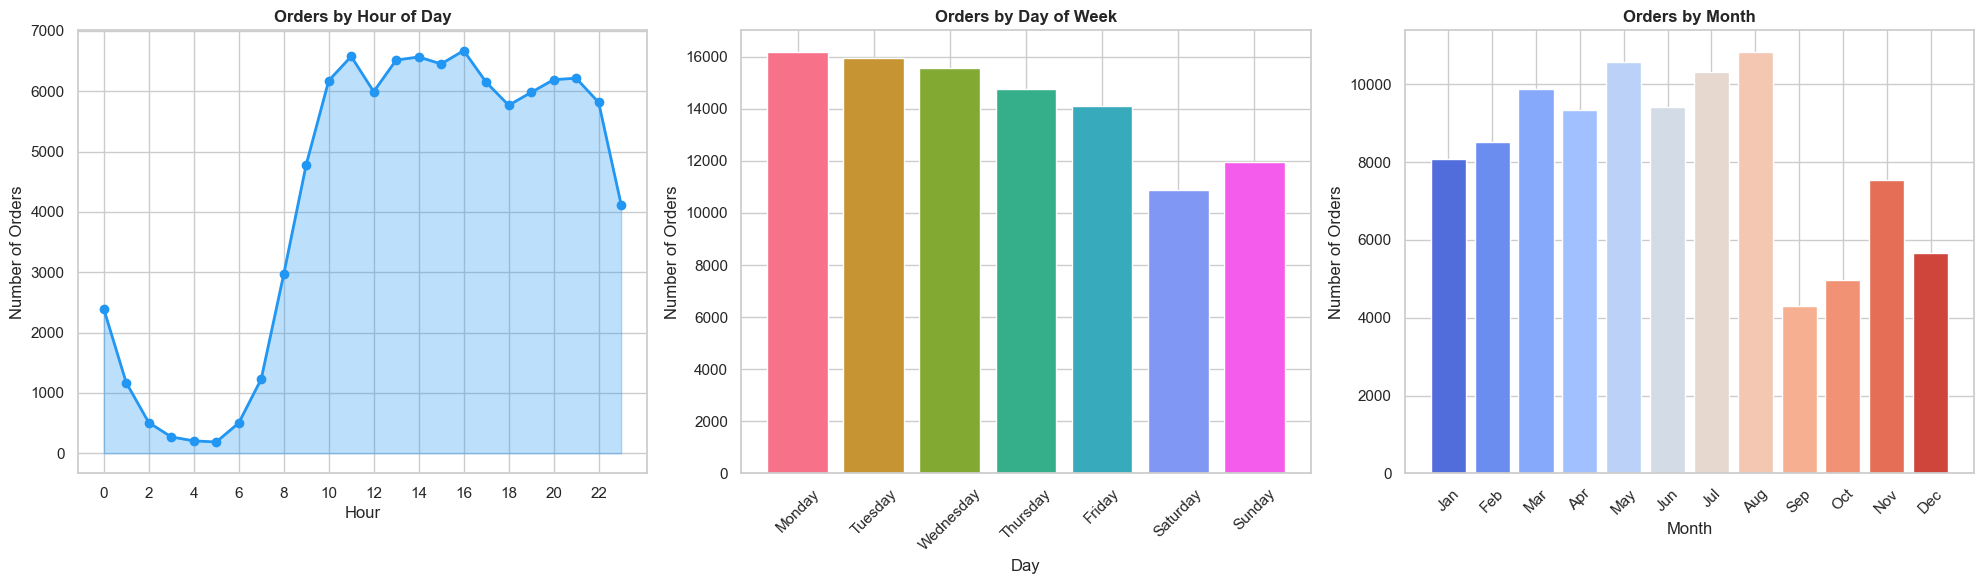

Peak Shopping Hour: 16:00
Peak Shopping Day: Monday


In [9]:
# BUSINESS QUESTION 7:
# When do customers shop the most?

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], errors='coerce')
orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour
orders['purchase_dayofweek'] = orders['order_purchase_timestamp'].dt.dayofweek
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month

day_names = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

hourly = orders.groupby('purchase_hour').size().reset_index(name='orders')
daily = orders.groupby('purchase_dayofweek').size().reset_index(name='orders')
monthly = orders.groupby('purchase_month').size().reset_index(name='orders')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Hourly
axes[0].plot(hourly['purchase_hour'], hourly['orders'],
             marker='o', color='#2196F3', linewidth=2)
axes[0].fill_between(hourly['purchase_hour'], hourly['orders'],
                     alpha=0.3, color='#2196F3')
axes[0].set_title('Orders by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticks(range(0, 24, 2))

# Daily
daily['day_name'] = daily['purchase_dayofweek'].map(
    dict(enumerate(day_names)))
axes[1].bar(daily['day_name'], daily['orders'],
            color=sns.color_palette("husl", 7))
axes[1].set_title('Orders by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

# Monthly
monthly['month_name'] = monthly['purchase_month'].map(
    dict(enumerate(month_names, 1)))
axes[2].bar(monthly['month_name'], monthly['orders'],
            color=sns.color_palette("coolwarm", 12))
axes[2].set_title('Orders by Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Orders')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/peak_time_analysis.png', dpi=150)
plt.show()

peak_hour = hourly.loc[hourly['orders'].idxmax(), 'purchase_hour']
peak_day = day_names[daily.loc[daily['orders'].idxmax(), 'purchase_dayofweek']]
print(f"Peak Shopping Hour: {peak_hour}:00")
print(f"Peak Shopping Day: {peak_day}")

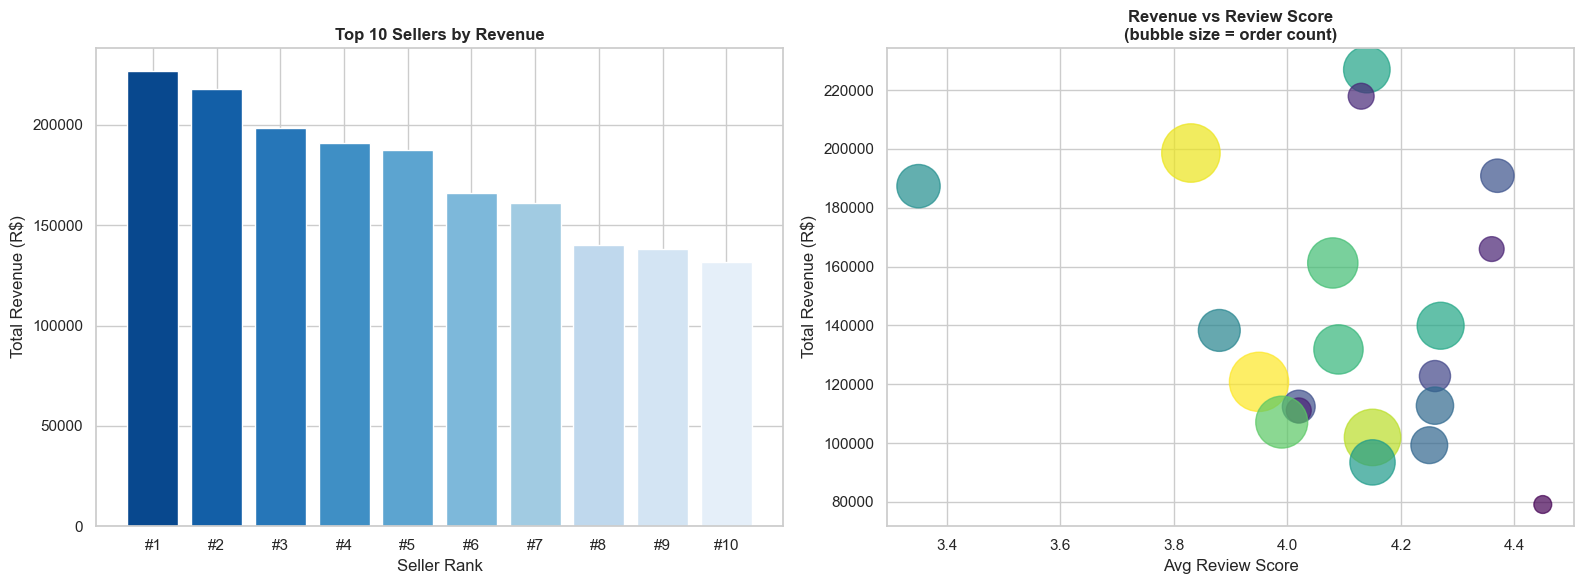


Top 20 Sellers Analysis:
seller_state  total_orders  total_revenue  avg_review_score
          SP          1124      226987.93              4.14
          BA           348      217940.44              4.13
          SP          1772      198631.52              3.83
          SP           578      190917.14              4.37
          SP           973      187366.92              3.35
          SP           319      165981.49              4.36
          SP          1311      161254.87              4.08
          SP          1145      139918.67              4.27
          SP           910      138323.76              3.88
          SP          1261      131861.71              4.09
          RJ           503      122811.38              4.26
          SP          1819      120841.83              3.95
          RJ           722      112751.10              4.26
          SP           558      112436.18              4.02
          SP           322      111126.73              4.02
          SP  

In [10]:
# BUSINESS QUESTION 8:
# Who are our top performing sellers?

query8 = """
SELECT
    s.seller_id,
    s.seller_state,
    s.seller_city,
    COUNT(DISTINCT oi.order_id) as total_orders,
    ROUND(SUM(oi.price), 2) as total_revenue,
    ROUND(AVG(oi.price), 2) as avg_price,
    ROUND(AVG(r.review_score), 2) as avg_review_score
FROM dim_sellers s
JOIN fact_order_items oi ON s.seller_id = oi.seller_id
JOIN dim_orders o ON oi.order_id = o.order_id
LEFT JOIN fact_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY s.seller_id
HAVING total_orders >= 50
ORDER BY total_revenue DESC
LIMIT 20
"""

top_sellers = pd.read_sql(query8, conn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top sellers by revenue
top10 = top_sellers.head(10)
axes[0].bar(range(len(top10)), top10['total_revenue'],
            color=sns.color_palette("Blues_r", 10))
axes[0].set_title('Top 10 Sellers by Revenue', fontweight='bold')
axes[0].set_xlabel('Seller Rank')
axes[0].set_ylabel('Total Revenue (R$)')
axes[0].set_xticks(range(len(top10)))
axes[0].set_xticklabels([f"#{i+1}" for i in range(len(top10))])

# Revenue vs Review Score scatter
axes[1].scatter(top_sellers['avg_review_score'],
                top_sellers['total_revenue'],
                s=top_sellers['total_orders'],
                c=top_sellers['total_orders'],
                cmap='viridis', alpha=0.7)
axes[1].set_title('Revenue vs Review Score\n(bubble size = order count)',
                  fontweight='bold')
axes[1].set_xlabel('Avg Review Score')
axes[1].set_ylabel('Total Revenue (R$)')

plt.tight_layout()
plt.savefig('../reports/seller_performance.png', dpi=150)
plt.show()

print(f"\nTop 20 Sellers Analysis:")
print(top_sellers[['seller_state', 'total_orders',
                   'total_revenue', 'avg_review_score']].to_string(index=False))

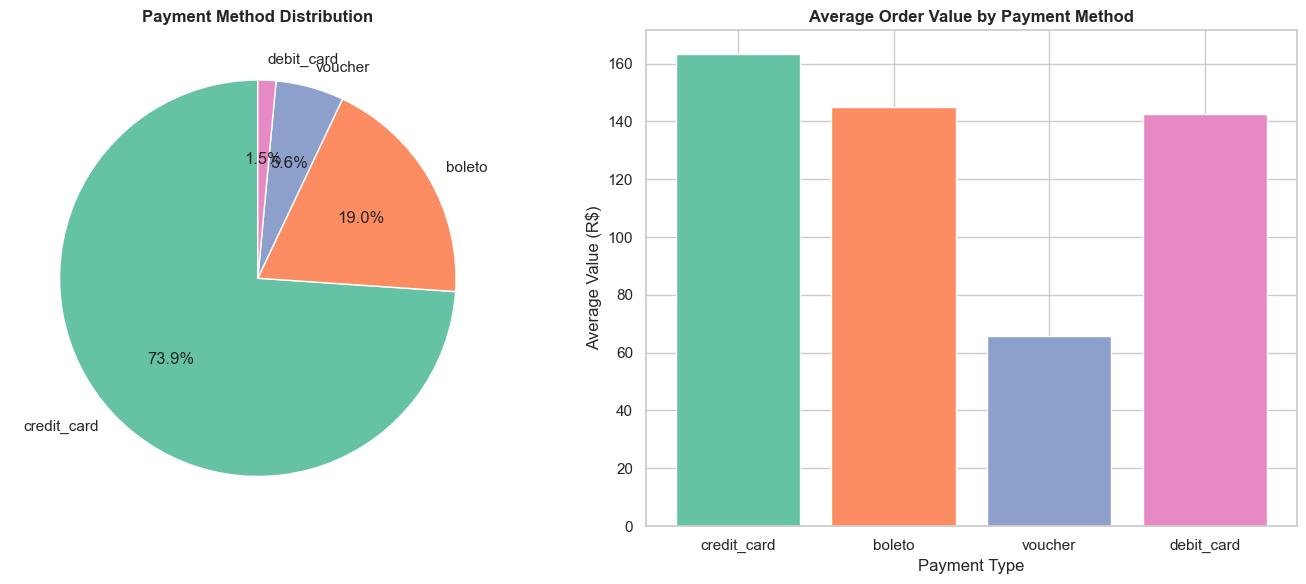


Payment Method Analysis:
payment_type  total_transactions  total_value  avg_value  avg_installments
 credit_card               76795  12542084.19     163.32              3.51
      boleto               19784   2869361.27     145.03              1.00
     voucher                5769    379436.87      65.77              1.00
  debit_card                1529    217989.79     142.57              1.00


In [11]:
# BUSINESS QUESTION 9:
# What payment methods do customers prefer?

query9 = """
SELECT
    payment_type,
    COUNT(*) as total_transactions,
    ROUND(SUM(payment_value), 2) as total_value,
    ROUND(AVG(payment_value), 2) as avg_value,
    ROUND(AVG(payment_installments), 2) as avg_installments
FROM fact_payments
GROUP BY payment_type
ORDER BY total_transactions DESC
"""

payment_analysis = pd.read_sql(query9, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = sns.color_palette("Set2", len(payment_analysis))

axes[0].pie(payment_analysis['total_transactions'],
            labels=payment_analysis['payment_type'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[0].set_title('Payment Method Distribution', fontweight='bold')

axes[1].bar(payment_analysis['payment_type'],
            payment_analysis['avg_value'],
            color=colors)
axes[1].set_title('Average Order Value by Payment Method',
                  fontweight='bold')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Average Value (R$)')

plt.tight_layout()
plt.savefig('../reports/payment_analysis.png', dpi=150)
plt.show()

print("\nPayment Method Analysis:")
print(payment_analysis.to_string(index=False))

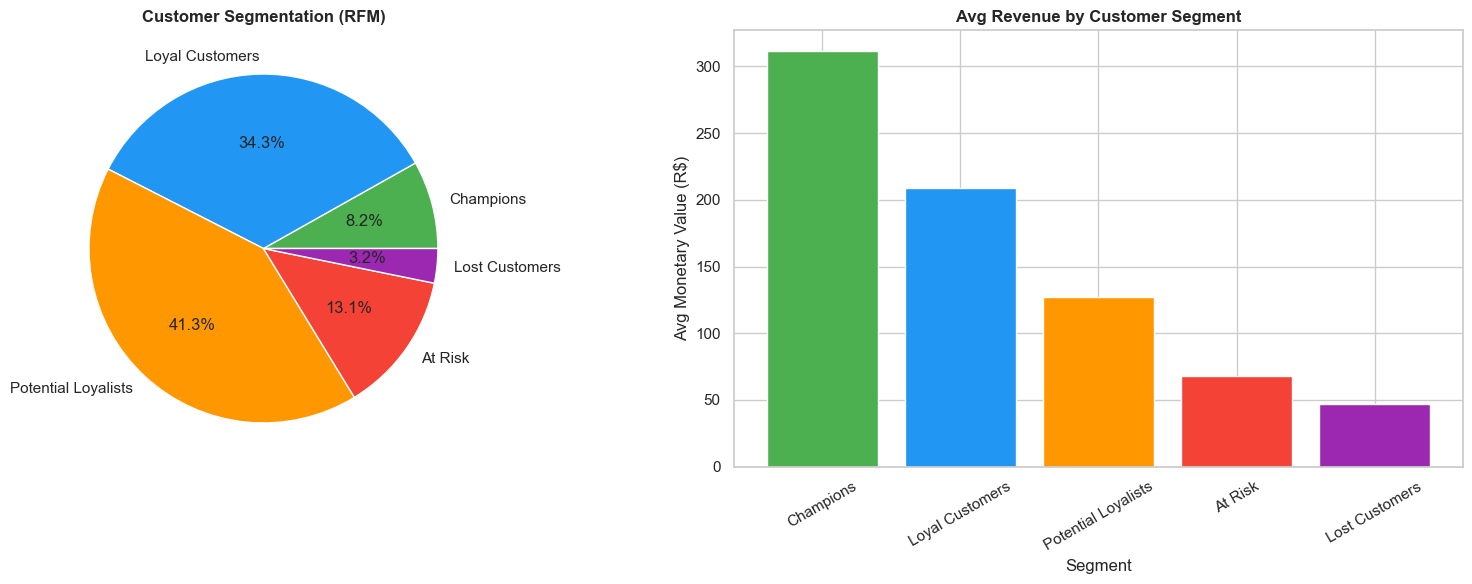


RFM Customer Segmentation Summary:
            Segment  total_customers  avg_monetary  avg_frequency  avg_recency
          Champions             7867        311.44           1.00        90.18
    Loyal Customers            33115        208.81           1.00       175.46
Potential Loyalists            39798        127.10           1.00       269.00
            At Risk            12618         67.81           1.00       356.32
     Lost Customers             3079         46.64           1.00       437.71


In [12]:
# BUSINESS QUESTION 10:
# Who are our most valuable customers? (RFM Analysis)
# RFM = Recency, Frequency, Monetary

rfm_query = """
SELECT
    o.customer_id,
    MAX(o.order_purchase_timestamp) as last_purchase,
    COUNT(DISTINCT o.order_id) as frequency,
    ROUND(SUM(p.payment_value), 2) as monetary
FROM dim_orders o
JOIN fact_payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY o.customer_id
"""

rfm = pd.read_sql(rfm_query, conn)
rfm['last_purchase'] = pd.to_datetime(rfm['last_purchase'], errors='coerce')

snapshot_date = rfm['last_purchase'].max()
rfm['recency'] = (snapshot_date - rfm['last_purchase']).dt.days

# Score each dimension 1-5
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 
                          5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (rfm['R_score'].astype(int) + 
                    rfm['F_score'].astype(int) + 
                    rfm['M_score'].astype(int))

# Segment customers
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

segment_summary = rfm.groupby('Segment').agg(
    total_customers=('customer_id', 'count'),
    avg_monetary=('monetary', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_recency=('recency', 'mean')
).reset_index().sort_values('avg_monetary', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0']

axes[0].pie(segment_summary['total_customers'],
            labels=segment_summary['Segment'],
            autopct='%1.1f%%',
            colors=colors)
axes[0].set_title('Customer Segmentation (RFM)', fontweight='bold')

axes[1].bar(segment_summary['Segment'],
            segment_summary['avg_monetary'],
            color=colors)
axes[1].set_title('Avg Revenue by Customer Segment',
                  fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg Monetary Value (R$)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/rfm_segmentation.png', dpi=150)
plt.show()

print("\nRFM Customer Segmentation Summary:")
print(segment_summary.to_string(index=False))

In [ ]:
# FINAL BUSINESS INSIGHTS DASHBOARD

print("="*60)
print("RETAIL SUPPLY CHAIN - EXECUTIVE SUMMARY")
print("="*60)

total_revenue = pd.read_sql("""
    SELECT ROUND(SUM(payment_value), 2) as revenue 
    FROM fact_payments
""", conn).iloc[0,0]

total_orders = pd.read_sql("""
    SELECT COUNT(DISTINCT order_id) as orders 
    FROM dim_orders 
    WHERE order_status='delivered'
""", conn).iloc[0,0]

total_customers = pd.read_sql("""
    SELECT COUNT(DISTINCT customer_id) as customers 
    FROM dim_customers
""", conn).iloc[0,0]

total_sellers = pd.read_sql("""
    SELECT COUNT(DISTINCT seller_id) as sellers 
    FROM dim_sellers
""", conn).iloc[0,0]

avg_review = pd.read_sql("""
    SELECT ROUND(AVG(review_score),2) as avg_score 
    FROM fact_reviews
""", conn).iloc[0,0]

print(f"\n Total Revenue : R$ {total_revenue:,.2f}")
print(f" Total Orders : {total_orders:,}")
print(f" Total Customers : {total_customers:,}")
print(f" Total Sellers : {total_sellers:,}")
print(f" Avg Review Score : {avg_review}/5.0")
print(f" Late Delivery Rate: {late_rate:.1f}%")
print(f" Peak Hour : {peak_hour}:00")
print(f" Peak Day : {peak_day}")

print("\n" + "="*60)
print("TOP BUSINESS INSIGHTS")
print("="*60)
print("""
  1. Revenue peaks in Q4 - holiday season drives sales
  2. Sao Paulo generates highest revenue by far
  3. Late deliveries correlate strongly with low reviews
  4. Credit card is most preferred payment method
  5. Health & Beauty is top revenue category
  6. Most orders placed between 10AM - 4PM
  7. Monday is peak shopping day
  8. Champions segment generates 3x more revenue
""")

print("="*60)
print("All charts saved to reports/ folder!")
print("="*60)

conn.close()

RETAIL SUPPLY CHAIN - EXECUTIVE SUMMARY
